In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8")

In [39]:
# Step1 - Generate Data
X,y = make_regression(n_samples=500, n_features=10, n_informative=5, noise=2, random_state=0)
print(X.shape, y.shape)

(500, 10) (500,)


In [40]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9
0,1.706468,1.511639,-0.000417,0.374155,0.073285,0.701783,0.409552,-0.461894,-0.626490,-0.799593
1,-1.616956,0.640132,-0.369182,-0.239379,-0.738031,-0.024326,1.099660,0.279925,-0.098150,0.655264
2,0.093953,-0.130107,0.929505,0.582225,-2.739677,0.943046,-2.094603,-0.569312,0.269904,0.123722
3,-1.542758,-0.789954,0.537035,-0.286835,-2.369623,-0.767332,1.634406,-0.260560,0.128957,0.571227
4,-0.101003,-2.231538,0.436187,1.571463,1.324868,-0.587375,1.077315,0.840648,0.261106,0.811090


In [41]:
# Step2 - Normalise
def normalise(X):
  u = X.mean(axis=0)
  std = X.std(axis=0)

  return (X-u)/std

In [42]:
X = normalise(X)
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9
0,1.764831,1.579606,0.093808,0.341546,0.103202,0.745205,0.421736,-0.461091,-0.710885,-0.761760
1,-1.612963,0.709920,-0.277540,-0.301827,-0.693297,-0.045695,1.116862,0.265971,-0.166048,0.714702
2,0.125936,-0.058708,1.030243,0.559735,-2.658385,1.007996,-2.100631,-0.566372,0.213499,0.175267
3,-1.537551,-0.717175,0.635024,-0.351591,-2.295090,-0.855000,1.655498,-0.263762,0.068151,0.629417
4,-0.072209,-2.155744,0.533470,1.597083,1.331926,-0.658985,1.094355,0.815541,0.204426,0.872842


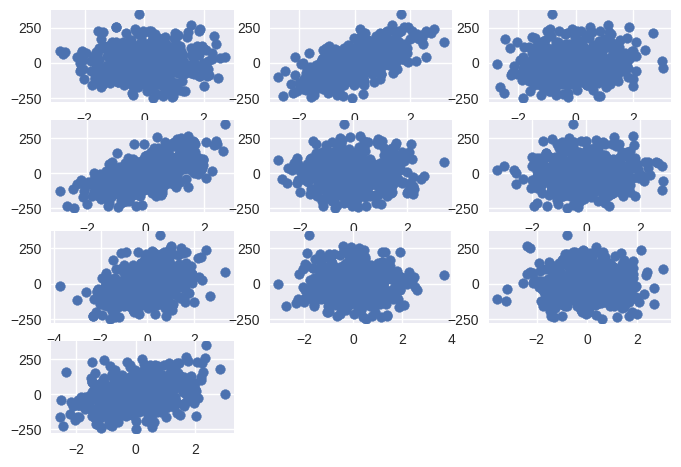

In [43]:
# Step3 - Visualise y as function of each feature
for f in range(0, 10):
  plt.subplot(4, 3, f+1)
  plt.scatter(X[:, f], y)
plt.show()

In [44]:
# Step4 - Train Test Split
XT, Xt, yT, yt = train_test_split(X, y, test_size=0.3, shuffle=False, random_state=0)

In [45]:
print(XT.shape, yT.shape)
print(Xt.shape, yt.shape)

(350, 10) (350,)
(150, 10) (150,)


In [46]:
# Step5 - Modelling / Linear Regression with Multiple Features

def preprocess(X):
  if X.shape[1] == n_features:
    m = X.shape[0]
    ones = np.ones((m, 1))
    X = np.hstack((ones, X))
  return X

In [47]:
def hypothesis(X, theta):
  return np.dot(X, theta)

def loss(X, y, theta):
  yp = hypothesis(X, theta)
  error = np.mean((y-yp)**2)
  return error

def gradient(X, y, theta):
  yp = hypothesis(X, theta)
  grad = np.dot(X.T, (yp-y))
  m = X.shape[0]
  return grad/m

def train(X, y, learning_rate=0.1, max_iters=100):
  n = X.shape[1]
  theta = np.random.randn(n)
  error_list = []

  for i in range(max_iters):
    e = loss(X, y, theta)
    error_list.append(e)
    grad = gradient(X, y, theta)
    theta = theta - learning_rate * grad

  plt.plot(error_list)
  return theta

[-1.65794178e-01  6.05019657e+01  1.04254910e+01  6.36019260e+01
 -4.25227276e-02 -2.16435117e-01  4.08343596e+01 -7.11856070e-02
 -5.30138713e-02  2.54786344e+01]


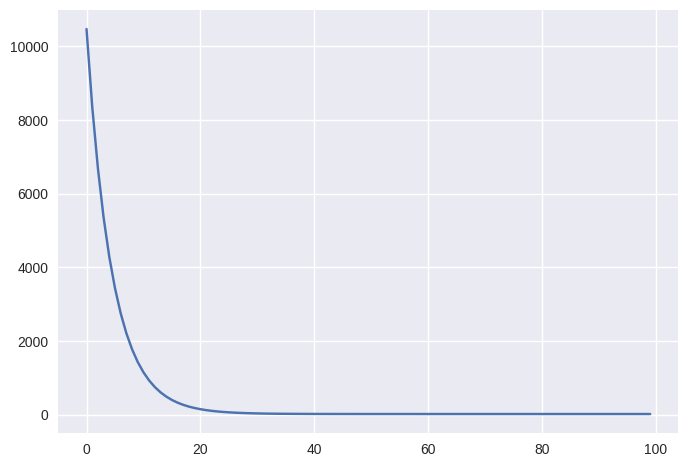

In [48]:
theta = train(XT, yT)
print(theta)

In [49]:
def r2Score(y, yp):
  ymean = y.mean()
  num = np.sum((y-yp)**2)
  denom = np.sum((y-ymean)**2)
  return (1 - num/denom)*100

In [50]:
yp = hypothesis(Xt, theta)

In [51]:
r2Score(yt, yp)

np.float64(99.82481711739422)